In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import tensorflow as tf
from src.NN_Utils import TimeSeriesRandomSearch, make_build_model
from src.Utils import plot_performance_analysis
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score

<h2>Lectura y Tratamiento de Datos</h2>

In [2]:
X = pd.read_csv('../dataset/dataset_in.txt', index_col=0).drop(columns=['P2', 'Q2'])
y_columns = [f'V{i}' for i in range(2,15)] + ['PERD', 'QGEN7'] #V1 ES SIEMPRE 1.0 EN DATASET
Y = pd.read_csv('../dataset/dataset_out.txt', index_col=0).loc[:, y_columns]
#FILTRAR DATOS ERRÓNEOS (PÉRDIDAS NEGATIVAS)
mask = Y['PERD'] >= 0
X = X[mask]
Y = Y[mask]

**Validación por Retención (Tratamiento como Serie Temporal)**

In [3]:
# VALIDACIÓN POR RETENCIÓN PARA EVALUACIÓN FINAL DEL MEJOR MODELO
n_samples = X.shape[0]
train_size = int(n_samples * 0.8)
x_train, y_train = X[:train_size], Y[:train_size]
x_test, y_test = X[train_size:], Y[train_size:]

<h2>Búsqueda de Mejores Modelos</h2>

In [4]:
input_dim = x_train.shape[1]
num_volts = len([c for c in y_train.columns if c.startswith('V')])
normalizer_layer = tf.keras.layers.Normalization(axis=-1)
normalizer_layer.adapt(x_train.values)
builder_function = make_build_model(input_dim, num_volts, normalizer_layer)

y_train_qgen = y_train[['QGEN7']]
y_train_perd = y_train[['PERD']]
y_train_volt = y_train.drop(columns=['QGEN7', 'PERD'])

tuner = TimeSeriesRandomSearch(builder_function, objective='val_loss', max_trials=10, overwrite=True, project_name='nn_random_search', seed=42)

In [5]:
tuner.search(
    x_train,
    y={
        'out_volt': y_train_volt,
        'out_perd': y_train_perd,
        'out_qgen7': y_train_qgen,
    },
    epochs=10,
    batch_size=32
)

Trial 10 Complete [00h 04m 42s]
val_loss: 0.012601261399686337

Best val_loss So Far: 0.009255200810730457
Total elapsed time: 00h 34m 32s


In [6]:
best_random_model = tuner.oracle.get_best_trials(1)[0]
for metric_name in best_random_model.metrics.metrics.keys():
    val = best_random_model.metrics.get_best_value(metric_name)
    print(f"{metric_name}: {val:.5f}")

val_loss: 0.00926
val_out_perd_loss: 0.00034
val_out_perd_mae: 0.01135
val_out_perd_mape: 6.30676
val_out_perd_r2_score: 0.98540
val_out_qgen7_loss: 0.00786
val_out_qgen7_mae: 0.05209
val_out_qgen7_mape: 8.75872
val_out_qgen7_r2_score: 0.79670
val_out_volt_loss: 0.00071
val_out_volt_mae: 0.02019
val_out_volt_mape: 138.97723
val_out_volt_r2_score: 0.96673


<h2>Evaluación del Mejor Modelo</h2>

In [7]:
best_random_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = builder_function(best_random_hp)
normalizer_qgen = MinMaxScaler(feature_range=(0, 1))
normalizer_volts = MinMaxScaler(feature_range=(0, 1))
normalizer_perd = MinMaxScaler(feature_range=(0, 1))
y_train_qgen_norm = normalizer_qgen.fit_transform(y_train_qgen)
y_train_perd_norm = normalizer_perd.fit_transform(y_train_perd)
y_train_volt_norm = normalizer_volts.fit_transform(y_train_volt)

In [8]:
results = best_model.fit(
    x_train,
    {
        'out_qgen7': y_train_qgen_norm,
        'out_volt': y_train_volt_norm,
        'out_perd': y_train_perd_norm
    },
    epochs=20,
    batch_size=32,
    validation_split=0.15,
    verbose=1
)

Epoch 1/20
2230/2230 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0441 - out_perd_loss: 0.0017 - out_perd_mae: 0.0276 - out_perd_mape: 639.0016 - out_perd_r2_score: 0.7748 - out_qgen7_loss: 0.0226 - out_qgen7_mae: 0.0981 - out_qgen7_mape: 11670.0293 - out_qgen7_r2_score: 0.4130 - out_volt_loss: 0.0180 - out_volt_mae: 0.0698 - out_volt_mape: 3305.8572 - out_volt_r2_score: -0.1539 - val_loss: 0.0153 - val_out_perd_loss: 4.0485e-04 - val_out_perd_mae: 0.0161 - val_out_perd_mape: 16.5129 - val_out_perd_r2_score: 0.9471 - val_out_qgen7_loss: 0.0125 - val_out_qgen7_mae: 0.0800 - val_out_qgen7_mape: 13.2169 - val_out_qgen7_r2_score: 0.6764 - val_out_volt_loss: 0.0019 - val_out_volt_mae: 0.0343 - val_out_volt_mape: 6.4304 - val_out_volt_r2_score: 0.8761
Epoch 2/20
2230/2230 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0134 - out_perd_loss: 5.9629e-04 - out_perd_mae: 0.0178 - out_perd_mape: 754.4384 - out_perd_r2_score: 0.9213 - out_qgen7_loss: 0.0108 - out_qgen7_mae: 0.0670 - out_qgen7_mape: 12599

In [9]:
predictions = best_model.predict(x_test)
pred_volts_norm = predictions[0]
pred_perd_norm = predictions[1]
pred_qgen_norm = predictions[2]
y_pred_volts = normalizer_volts.inverse_transform(pred_volts_norm)
y_pred_perd = normalizer_perd.inverse_transform(pred_perd_norm)
y_pred_qgen = normalizer_qgen.inverse_transform(pred_qgen_norm)
y_pred = pd.DataFrame(np.hstack([y_pred_volts, y_pred_perd, y_pred_qgen]), columns=y_test.columns, index=y_test.index)

656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step


In [10]:
evaluate_MAE = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
evaluate_MAPE = mean_absolute_percentage_error(y_test, y_pred, multioutput='raw_values')
#DESPLAZAMIENTO PARA EVITAR DIVISIÓN POR VALORES CERCANO A 0. CONSECUENCIA: MAPE ALGO OPTIMISTA
evaluate_MAPE_shifted = mean_absolute_percentage_error(y_test + 1.0, y_pred + 1.0, multioutput='raw_values')
evaluate_R2 = r2_score(y_test, y_pred, multioutput='raw_values')

In [11]:
# RESULTADOS CON MAPE DESPLAZADO
evaluate_data_score_shifted = np.vstack([evaluate_MAE, evaluate_MAPE_shifted, evaluate_R2])
evaluations_shifted = pd.DataFrame(evaluate_data_score_shifted, columns=y_columns, index=['MAE', 'MAPE', 'R2'])
evaluations_shifted

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.001817,0.001811,0.001833,0.001778,0.001781,0.001777,0.001801,0.001818,0.001854,0.001814,0.001790,0.001048,0.001082,0.198387,0.009406
MAPE,0.000921,0.000918,0.000930,0.000902,0.000903,0.000901,0.000913,0.000922,0.000940,0.000920,0.000908,0.000529,0.000546,0.024880,0.008919
R2,0.971005,0.971540,0.971123,0.972656,0.972612,0.972753,0.972050,0.971675,0.970635,0.971689,0.972326,0.986161,0.985522,0.981558,0.856210


In [12]:
# RESULTADOS SIN DESPLAZADO
evaluate_data_score = np.vstack([evaluate_MAE, evaluate_MAPE, evaluate_R2])
evaluations = pd.DataFrame(evaluate_data_score, columns=y_columns, index=['MAE', 'MAPE', 'R2'])
evaluations

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.001817,0.001811,0.001833,0.001778,0.001781,0.001777,0.001801,0.001818,0.001854,0.001814,0.001790,0.001048,0.001082,0.198387,9.405857e-03
MAPE,0.001867,0.001863,0.001886,0.001830,0.001834,0.001830,0.001854,0.001871,0.001908,0.001868,0.001843,0.001067,0.001101,0.029969,1.797226e+13
R2,0.971005,0.971540,0.971123,0.972656,0.972612,0.972753,0.972050,0.971675,0.970635,0.971689,0.972326,0.986161,0.985522,0.981558,8.562096e-01


In [13]:
# EVALUACIÓN FINAL CON MEDIA DE VOLTAJES (MAPE DESPLAZADO)
volts_columns = [c for c in y_train.columns if c.startswith('V')]
pd.DataFrame({
    'Voltajes (Desplazados)': evaluations_shifted[volts_columns].mean(axis=1),
    'Pérdidas (Desplazada)': evaluations_shifted['PERD'],
    'Potencia Reactiva (Desplazada)': evaluations_shifted['QGEN7']
})

,Voltajes (Desplazados),Pérdidas (Desplazada),Potencia Reactiva (Desplazada)
MAE,0.001693,0.198387,0.009406
MAPE,0.000858,0.024880,0.008919
R2,0.973980,0.981558,0.856210


In [14]:
# EVALUACIÓN FINAL CON MEDIA DE VOLTAJES (MAPE SIN DESPLAZAMIENTO)
pd.DataFrame({
    'Voltajes': evaluations[volts_columns].mean(axis=1),
    'Pérdidas': evaluations['PERD'],
    'Potencia Reactiva': evaluations['QGEN7']
})

,Voltajes,Pérdidas,Potencia Reactiva
MAE,0.001693,0.198387,9.405857e-03
MAPE,0.001740,0.029969,1.797226e+13
R2,0.973980,0.981558,8.562096e-01


<h2>Figuras de Rendimiento del Mejor Modelo</h2>

In [15]:
best_model.save('../models/MO_NeuralNetwork.keras')

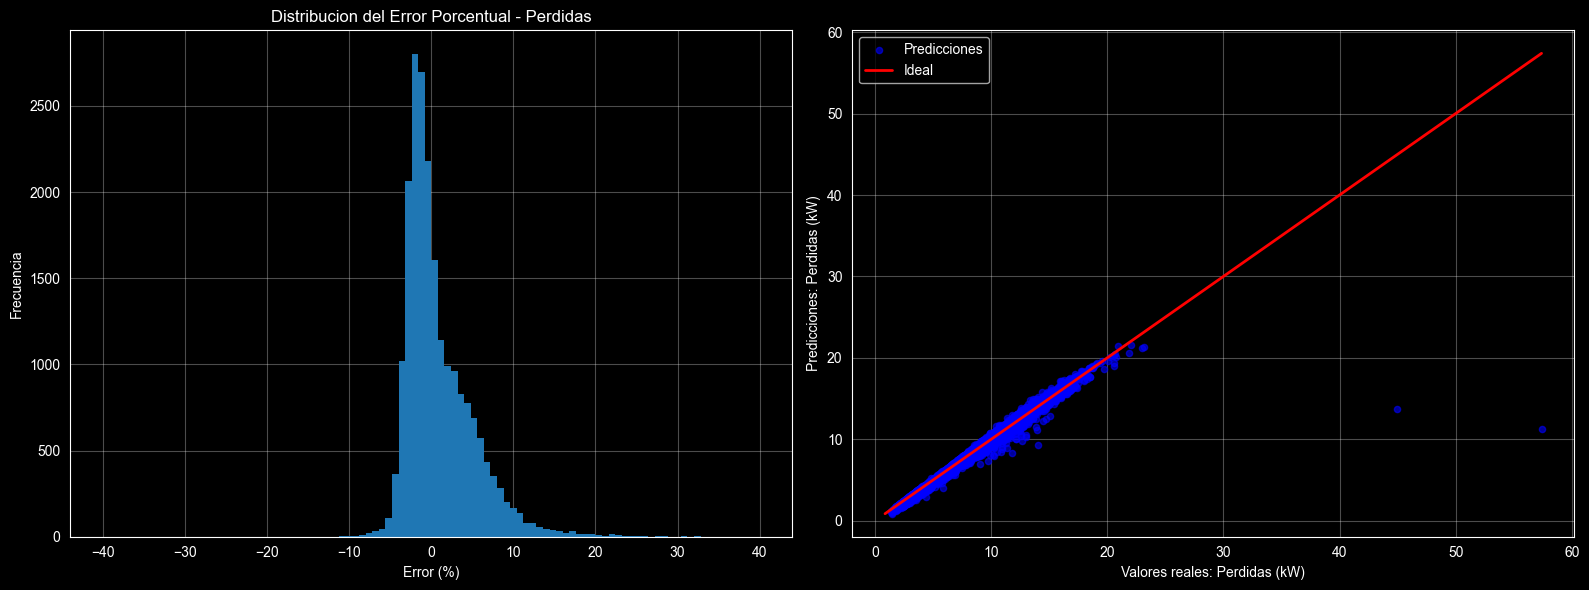

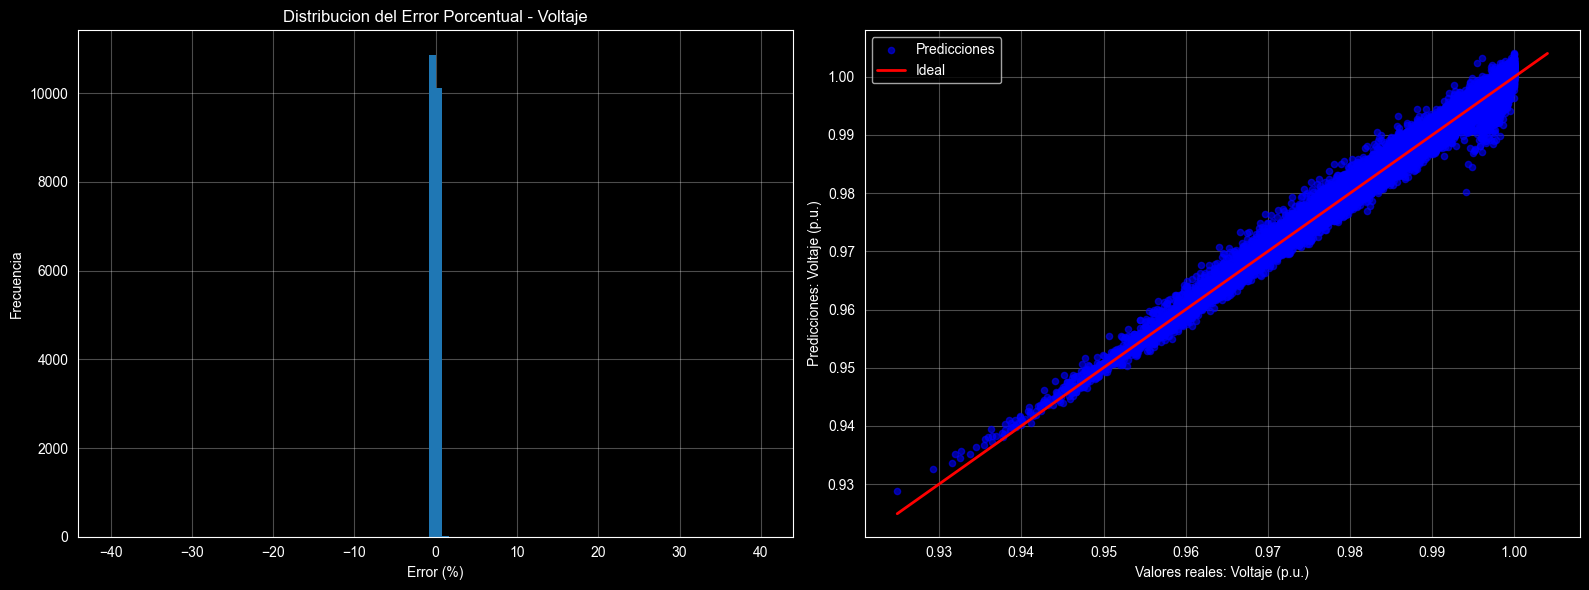

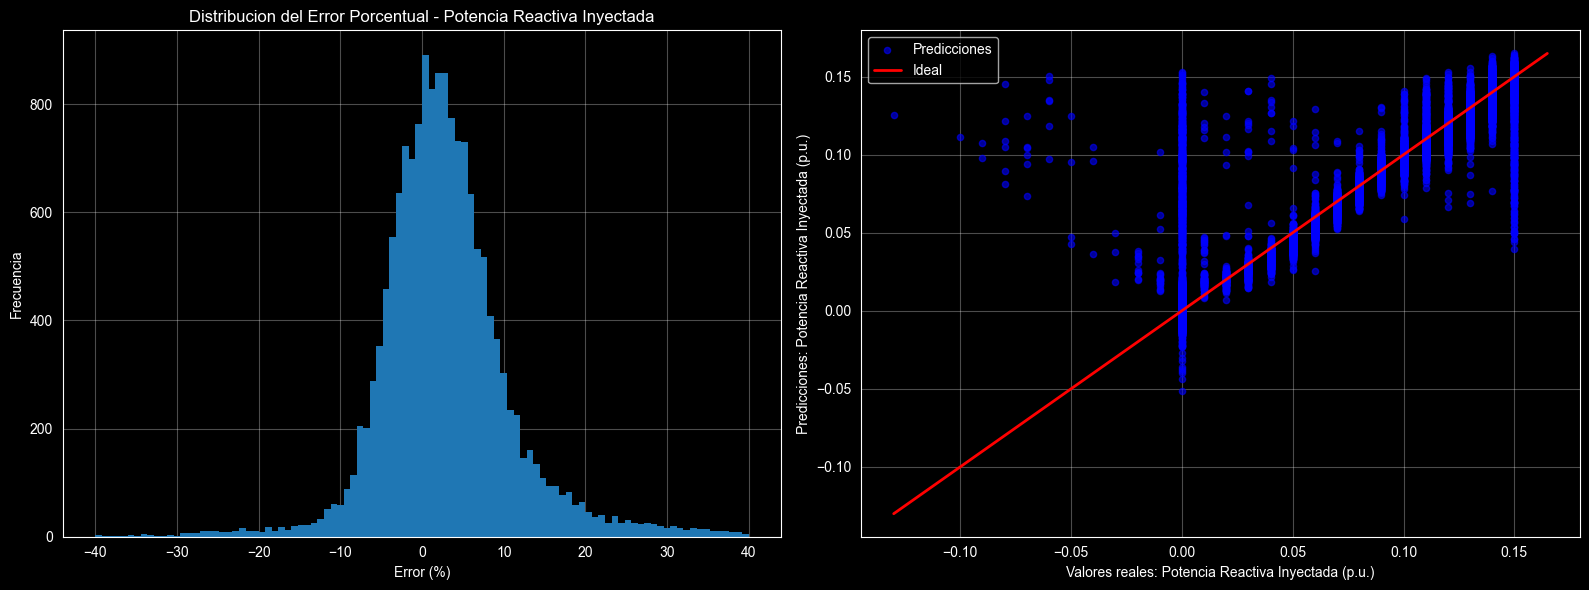

In [16]:
plot_performance_analysis(
    y_test['PERD'],
    y_pred.iloc[:, -2],
    variable_name="Perdidas",
    unit_label="kW",
    path='../figures/NeuralNetwork/MO_NeuralNetwork_Perd.png'
)
plot_performance_analysis(
    y_test['V13'],
    y_pred.loc[:, 'V13'],
    variable_name="Voltaje",
    unit_label="p.u.",
    path='../figures/NeuralNetwork/MO_NeuralNetwork_V13.png'
)
plot_performance_analysis(
    y_test['QGEN7'],
    y_pred.iloc[:, -1],
    variable_name="Potencia Reactiva Inyectada",
    unit_label="p.u.",
    path='../figures/NeuralNetwork/MO_NeuralNetwork_QGen.png'
)